# 📈 Tahap 5: Evaluation
**Proyek:** Analisis Sentimen Produk Bummitanni (Tepung Ketan Hitam) — Shopee  
**Metodologi:** CRISP-DM  
**Tahap:** 5 dari 6 — Evaluation

---
Tujuan tahap ini:
- Mengevaluasi performa model terbaik secara mendalam
- Menampilkan confusion matrix dan laporan klasifikasi
- Menganalisis hasil prediksi dan kesalahan
- Menyimpulkan apakah model sudah memenuhi tujuan bisnis

## 📦 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
os.makedirs('output_evaluation', exist_ok=True)
print('✅ Library berhasil diimpor!')

✅ Library berhasil diimpor!


## 📂 2. Load Model & Dataset

In [2]:
df = pd.read_csv('../3-Data-Preparation/output_preparation/ulasan_clean.csv')
model  = joblib.load('../4-Modeling/output_modeling/best_model.pkl')
tfidf  = joblib.load('../4-Modeling/output_modeling/tfidf_vectorizer.pkl')

X = df['Teks_Clean'].fillna('')
y = df['Sentimen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test_tfidf = tfidf.transform(X_test)

print(f'✅ Model & dataset dimuat')
print(f'   Jenis model : {type(model).__name__}')
print(f'   Data testing: {len(X_test)} sampel')

✅ Model & dataset dimuat
   Jenis model : LinearSVC
   Data testing: 97 sampel


## 📋 3. Laporan Klasifikasi Lengkap

In [3]:
y_pred = model.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('=== Metrik Evaluasi Model ===')
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, zero_division=0))

=== Metrik Evaluasi Model ===
  Accuracy  : 0.8660  (86.60%)
  Precision : 0.8320
  Recall    : 0.8660
  F1-Score  : 0.8407

=== Classification Report ===
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         4
      Netral       0.78      0.47      0.58        15
     Positif       0.89      0.99      0.93        78

    accuracy                           0.87        97
   macro avg       0.55      0.48      0.51        97
weighted avg       0.83      0.87      0.84        97



## 🗺️ 4. Confusion Matrix

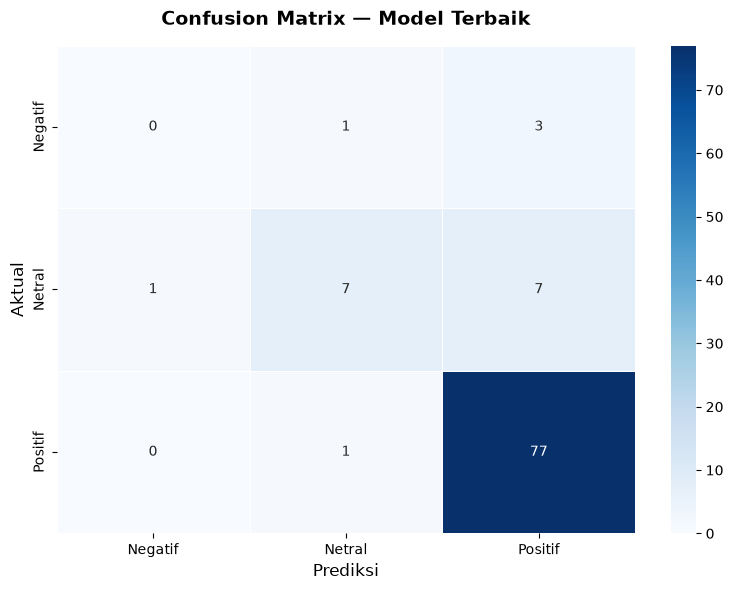

In [4]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Confusion Matrix — Model Terbaik', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Prediksi', fontsize=12)
ax.set_ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.savefig('output_evaluation/1-confusion-matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 🔄 5. Cross-Validation (5-Fold)

=== 5-Fold Cross-Validation ===
  Fold 1: 0.8454
  Fold 2: 0.8557
  Fold 3: 0.8660
  Fold 4: 0.8351
  Fold 5: 0.8646

  Rata-rata : 0.8533
  Std Dev   : 0.0117


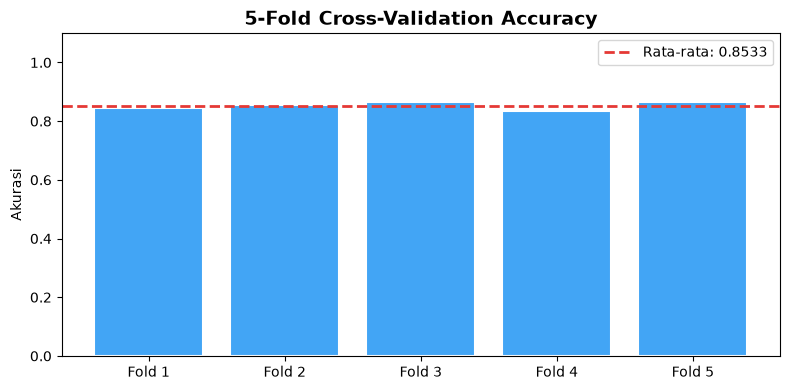

In [5]:
X_all_tfidf = tfidf.transform(X)
cv_scores = cross_val_score(model, X_all_tfidf, y, cv=5, scoring='accuracy')

print('=== 5-Fold Cross-Validation ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Rata-rata : {cv_scores.mean():.4f}')
print(f'  Std Dev   : {cv_scores.std():.4f}')

# Visualisasi CV
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'Fold {i}' for i in range(1, 6)], cv_scores,
       color='#42A5F5', edgecolor='white', linewidth=1.5)
ax.axhline(cv_scores.mean(), color='#E53935', linestyle='--', linewidth=2,
           label=f'Rata-rata: {cv_scores.mean():.4f}')
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Akurasi')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('output_evaluation/2-cross-validation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 🔍 6. Analisis Contoh Prediksi

In [6]:
# Tampilkan sampel prediksi benar dan salah
hasil_df = X_test.reset_index(drop=True).to_frame()
hasil_df['Aktual']  = y_test.reset_index(drop=True)
hasil_df['Prediksi'] = y_pred
hasil_df['Benar'] = hasil_df['Aktual'] == hasil_df['Prediksi']

print('=== Contoh Prediksi BENAR ===')
display(hasil_df[hasil_df['Benar']].head(5))

print('\n=== Contoh Prediksi SALAH ===')
salah = hasil_df[~hasil_df['Benar']]
if len(salah) > 0:
    display(salah.head(5))
else:
    print('  (Tidak ada prediksi yang salah!)')

=== Contoh Prediksi BENAR ===


,Teks_Clean,Aktual,Prediksi,Benar
0,paket terima thanks seller shopee,Positif,Positif,True
1,tekstur bagus guna kue alhamdulillah paket sdh...,Netral,Netral,True
2,pesan kk terimakasih kualitas bagus coba smoga...,Positif,Positif,True
3,ok tekstur ok guna ok,Positif,Positif,True
4,sesuai pesan packing rapih aman kirim cepet te...,Positif,Positif,True



=== Contoh Prediksi SALAH ===


,Teks_Clean,Aktual,Prediksi,Benar
8,muas milo dancow,Positif,Netral,False
31,tepung murah riah mantul kalah harga mahal top...,Negatif,Positif,False
33,lezatt tekstur lembut guna cocok kue kirim cep...,Netral,Positif,False
37,tekstur teksturnua lembut tepung harum rasa ha...,Netral,Positif,False
46,mantap sesuai ucap terima kasih kunjung selamat,Netral,Positif,False


## 🎯 7. Uji Prediksi Manual

In [7]:
def prediksi_sentimen(kalimat):
    """Prediksi sentimen dari teks baru."""
    vec = tfidf.transform([kalimat])
    pred = model.predict(vec)[0]
    emoji = {'Positif': '😊', 'Netral': '😐', 'Negatif': '😞'}.get(pred, '')
    print(f'  Input     : "{kalimat}"')
    print(f'  Sentimen  : {pred} {emoji}')
    print()

# Contoh uji
contoh_ulasan = [
    'tepung ketan hitamnya enak banget warnanya pekat dan lembut',
    'barang bocor pas sampai kecewa banget',
    'lumayan lah harga sesuai kualitas'
]

print('=== Uji Prediksi Manual ===')
for ulasan in contoh_ulasan:
    prediksi_sentimen(ulasan)

=== Uji Prediksi Manual ===
  Input     : "tepung ketan hitamnya enak banget warnanya pekat dan lembut"
  Sentimen  : Positif 😊

  Input     : "barang bocor pas sampai kecewa banget"
  Sentimen  : Negatif 😞

  Input     : "lumayan lah harga sesuai kualitas"
  Sentimen  : Positif 😊



## 📝 8. Kesimpulan Evaluasi

In [8]:
print('=' * 62)
print('       KESIMPULAN EVALUASI MODEL')
print('=' * 62)
print(f'  Model yang digunakan   : {type(model).__name__}')
print(f'  Akurasi (test set)     : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision (weighted)   : {prec:.4f}')
print(f'  Recall (weighted)      : {rec:.4f}')
print(f'  F1-Score (weighted)    : {f1:.4f}')
print(f'  CV 5-Fold (rata-rata)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print('  KESESUAIAN DENGAN TUJUAN BISNIS:')
print('  → Model dapat mengklasifikasikan ulasan pembeli')
print('    menjadi 3 kategori: Positif, Netral, Negatif')
print('  → Informasi ini berguna bagi Bummitanni untuk')
print('    memahami kepuasan pelanggan secara otomatis')
print()
print('✅ Tahap 5: Evaluation — SELESAI')
print('   Lanjut → Tahap 6: Deployment')

       KESIMPULAN EVALUASI MODEL
  Model yang digunakan   : LinearSVC
  Akurasi (test set)     : 0.8660 (86.60%)
  Precision (weighted)   : 0.8320
  Recall (weighted)      : 0.8660
  F1-Score (weighted)    : 0.8407
  CV 5-Fold (rata-rata)  : 0.8533 ± 0.0117

  KESESUAIAN DENGAN TUJUAN BISNIS:
  → Model dapat mengklasifikasikan ulasan pembeli
    menjadi 3 kategori: Positif, Netral, Negatif
  → Informasi ini berguna bagi Bummitanni untuk
    memahami kepuasan pelanggan secara otomatis

✅ Tahap 5: Evaluation — SELESAI
   Lanjut → Tahap 6: Deployment
